## Exploratory Data Analysis for a collaborative filtering approach

In [9]:
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, accuracy_score

In [7]:
# read in cleaned csvs
bills_df = pd.read_csv("../../data/bills/bills_with_topic.csv")
votes_df = pd.read_csv("../../data/votes/votes.csv")
senators_df = pd.read_csv("../../data/senators/all_senators_with_bios.csv")

In [14]:
# Load and build the senator-bill matrix

# encode vote as numeric
vote_map = {'Yea': 1, 'Nay': -1, 'Not Voting': 0, 'Present': 0}
votes_df['vote_numeric'] = votes_df['vote'].map(vote_map)

# pivot to senator x bill matrix
vote_matrix = votes_df.pivot_table(
    index='senator_id',
    columns='bill_id',
    values='vote_numeric'
)

# fill NaN with 0 for computation — missing vote treated as no signal
vote_matrix_filled = vote_matrix.fillna(0).values  # numpy array
senator_ids = vote_matrix.index.tolist()
bill_ids    = vote_matrix.columns.tolist()

print(f'Matrix shape: {vote_matrix.shape}')
print(f'Sparsity: {vote_matrix.isna().mean().mean():.1%} missing')

Matrix shape: (326, 700)
Sparsity: 68.3% missing


---
## Method 1 — Memory-Based Collaborative Filtering

Compute cosine similarity between every pair of senators based on their vote vectors.
To predict a senator's vote on a bill they didn't vote on, take a weighted average
of the K most similar senators who did vote on that bill.

In [15]:
# compute senator-senator cosine similarity matrix (326 x 326)
sim_matrix = cosine_similarity(vote_matrix_filled)
sim_df = pd.DataFrame(sim_matrix, index=senator_ids, columns=senator_ids)

print(f'Similarity matrix shape: {sim_df.shape}')
print(f'Mean similarity between senators: {sim_matrix[sim_matrix < 1].mean():.3f}')

Similarity matrix shape: (326, 326)
Mean similarity between senators: 0.153


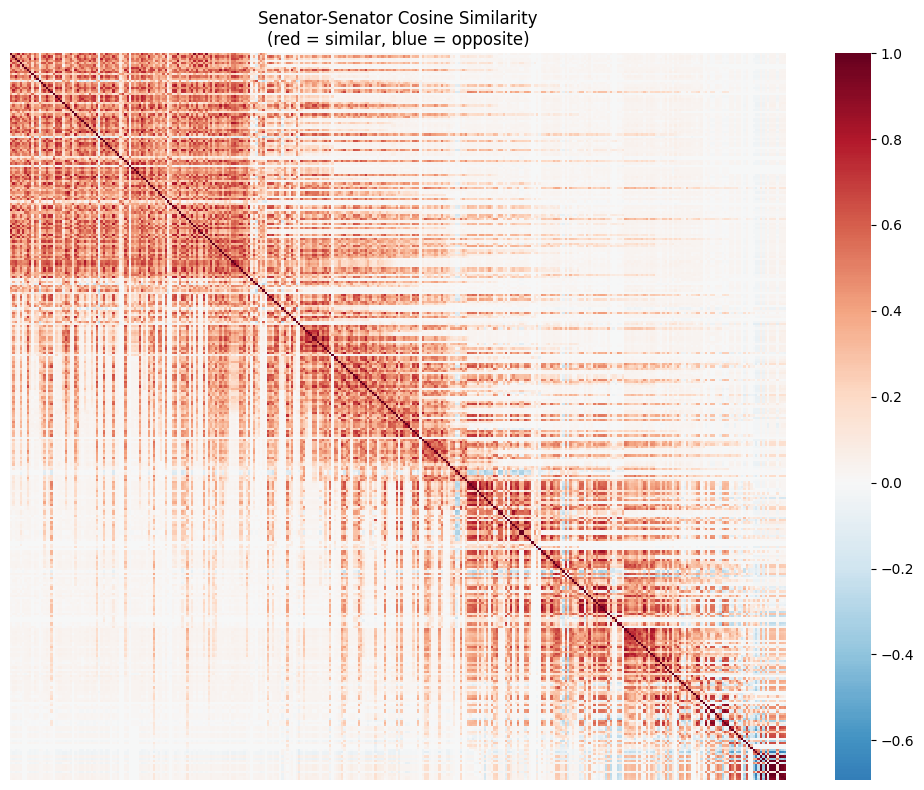

In [16]:
# visualize the similarity matrix — senators cluster by party
plt.figure(figsize=(10, 8))
sns.heatmap(sim_df.values, cmap='RdBu_r', center=0,
            xticklabels=False, yticklabels=False)
plt.title('Senator-Senator Cosine Similarity\n(red = similar, blue = opposite)')
plt.tight_layout()
plt.show()

In [17]:
def predict_vote_memory(senator_id, bill_id, vote_matrix, sim_df, k=10):
    """
    Predict how senator_id would vote on bill_id using the K most similar
    senators who actually voted on that bill.

    Returns a float in [-1, 1]: positive = predicted Yea, negative = predicted Nay.
    Returns None if no similar senator voted on the bill.
    """
    if bill_id not in vote_matrix.columns:
        return None

    bill_votes = vote_matrix[bill_id].dropna()          # senators who voted on this bill
    bill_votes = bill_votes[bill_votes != 0]             # exclude abstains
    other_senators = bill_votes.index.tolist()

    if senator_id not in sim_df.index or len(other_senators) == 0:
        return None

    # get similarity scores to senators who voted on this bill
    similarities = sim_df.loc[senator_id, other_senators]

    # take top K most similar (excluding self)
    similarities = similarities[similarities.index != senator_id]
    top_k = similarities.nlargest(k)

    if top_k.sum() == 0:
        return None

    # weighted average of their votes
    weighted_votes = sum(top_k[s] * bill_votes[s] for s in top_k.index)
    prediction = weighted_votes / top_k.abs().sum()
    return prediction

In [18]:
# quick demo — predict a known vote and compare to actual
sample_senator = senator_ids[0]
sample_bill    = bill_ids[0]
actual_vote    = vote_matrix.loc[sample_senator, sample_bill]

pred = predict_vote_memory(sample_senator, sample_bill, vote_matrix, sim_df, k=10)
print(f'Senator: {sample_senator}')
print(f'Bill:    {sample_bill}')
print(f'Actual:  {actual_vote} ({"Yea" if actual_vote == 1 else "Nay" if actual_vote == -1 else "Abstain"})')
print(f'Predicted score: {pred:.3f} ({"leans Yea" if pred > 0 else "leans Nay"})')

Senator: S009
Bill:    H.Con.Res. 64
Actual:  nan (Abstain)
Predicted score: 0.631 (leans Yea)


In [19]:
# evaluate memory-based model: hide known votes and try to predict them
# sample 500 known (non-zero, non-NaN) votes to evaluate on
known_votes = votes_df[votes_df['vote_numeric'] != 0][['senator_id', 'bill_id', 'vote_numeric']]
sample = known_votes.sample(n=min(500, len(known_votes)), random_state=42)

actuals = []
predictions = []

for _, row in sample.iterrows():
    pred = predict_vote_memory(row['senator_id'], row['bill_id'], vote_matrix, sim_df, k=10)
    if pred is not None:
        actuals.append(row['vote_numeric'])
        predictions.append(pred)

# convert continuous prediction to binary (-1 or 1) for accuracy
pred_binary = [1 if p > 0 else -1 for p in predictions]

mae = mean_absolute_error(actuals, predictions)
acc = accuracy_score(actuals, pred_binary)

print(f'Memory-based results (n={len(actuals)} predictions):')
print(f'  Accuracy:  {acc:.3f}')
print(f'  MAE:       {mae:.3f}')

Memory-based results (n=481 predictions):
  Accuracy:  0.923
  MAE:       0.218


In [20]:
# find the most similar pairs of senators
sim_upper = sim_df.where(np.triu(np.ones(sim_df.shape), k=1).astype(bool))
top_pairs = (
    sim_upper.stack()
    .reset_index()
    .rename(columns={'senator_id': 'senator_a', 'bill_id': 'senator_b', 0: 'similarity'})
    .sort_values('similarity', ascending=False)
    .head(10)
)
print('Most similar senator pairs:')
print(top_pairs.to_string(index=False))

Most similar senator pairs:
level_0 level_1  similarity
   S431    S435         1.0
   S433    S435         1.0
   S433    S434         1.0
   S433    S437         1.0
   S434    S437         1.0
   S431    S437         1.0
   S431    S434         1.0
   S434    S435         1.0
   S431    S433         1.0
   S435    S437         1.0


In [21]:
# find the most opposite senators (highest negative similarity)
bottom_pairs = (
    sim_upper.stack()
    .reset_index()
    .rename(columns={'senator_id': 'senator_a', 'bill_id': 'senator_b', 0: 'similarity'})
    .sort_values('similarity', ascending=True)
    .head(10)
)
print('Most opposite senator pairs:')
print(bottom_pairs.to_string(index=False))

Most opposite senator pairs:
level_0 level_1  similarity
   S427    S437   -0.692308
   S427    S435   -0.692308
   S427    S434   -0.692308
   S427    S433   -0.692308
   S427    S431   -0.692308
   S427    S429   -0.662344
   S427    S438   -0.640513
   S427    S439   -0.585369
   S417    S427   -0.547949
   S416    S427   -0.471728


---
## Method 2 — Model-Based: SVD Matrix Factorization

Decompose the senator-bill matrix into latent factors using Truncated SVD.
Each senator gets a low-dimensional embedding representing their ideology,
and each bill gets an embedding representing its ideological valence.

A predicted vote is the dot product of a senator's embedding and a bill's embedding.

The first latent factor almost always recovers something close to a left-right
ideology score — a good sanity check against NOMINATE dim1.

In [22]:
# fit SVD with n_components latent dimensions
# start with 20 — captures most variance without overfitting on 326 senators
N_COMPONENTS = 20

svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=42)
senator_factors = svd.fit_transform(vote_matrix_filled)  # (326, 20)
bill_factors    = svd.components_                        # (20, 700)

print(f'Senator factors shape: {senator_factors.shape}')
print(f'Bill factors shape:    {bill_factors.shape}')
print(f'Variance explained by each component:')
print(np.round(svd.explained_variance_ratio_, 3))
print(f'Total variance explained: {svd.explained_variance_ratio_.sum():.1%}')

Senator factors shape: (326, 20)
Bill factors shape:    (20, 700)
Variance explained by each component:
[0.193 0.136 0.097 0.068 0.044 0.03  0.024 0.017 0.015 0.013 0.011 0.01
 0.009 0.008 0.008 0.007 0.007 0.006 0.006 0.006]
Total variance explained: 71.7%


In [23]:
# reconstruct the full matrix from the factorization
reconstructed = senator_factors @ bill_factors  # (326, 700)

print(f'Reconstructed matrix shape: {reconstructed.shape}')
print(f'Value range: [{reconstructed.min():.3f}, {reconstructed.max():.3f}]')

Reconstructed matrix shape: (326, 700)
Value range: [-1.811, 2.192]


In [24]:
# evaluate SVD model on the same 500 sample votes
senator_idx = {s: i for i, s in enumerate(senator_ids)}
bill_idx    = {b: i for i, b in enumerate(bill_ids)}

actuals_svd = []
predictions_svd = []

for _, row in sample.iterrows():
    sid = row['senator_id']
    bid = row['bill_id']
    if sid in senator_idx and bid in bill_idx:
        pred = reconstructed[senator_idx[sid], bill_idx[bid]]
        actuals_svd.append(row['vote_numeric'])
        predictions_svd.append(pred)

pred_binary_svd = [1 if p > 0 else -1 for p in predictions_svd]

mae_svd = mean_absolute_error(actuals_svd, predictions_svd)
acc_svd = accuracy_score(actuals_svd, pred_binary_svd)

print(f'SVD results (n={len(actuals_svd)} predictions):')
print(f'  Accuracy:  {acc_svd:.3f}')
print(f'  MAE:       {mae_svd:.3f}')

SVD results (n=481 predictions):
  Accuracy:  0.933
  MAE:       0.300


In [25]:
# the first SVD component should recover left-right ideology
# plot it and compare to NOMINATE scores if available
senator_dim1 = senator_factors[:, 0]  # first latent factor per senator

svd_ideology = pd.DataFrame({
    'senator_id':  senator_ids,
    'svd_dim1':    senator_dim1,
    'svd_dim2':    senator_factors[:, 1]
})

svd_ideology = svd_ideology.sort_values('svd_dim1')
print('Most liberal senators by SVD dim1 (most negative):')
print(svd_ideology.head(5)[['senator_id', 'svd_dim1']].to_string(index=False))
print('\nMost conservative senators by SVD dim1 (most positive):')
print(svd_ideology.tail(5)[['senator_id', 'svd_dim1']].to_string(index=False))

Most liberal senators by SVD dim1 (most negative):
senator_id  svd_dim1
      S346 -0.514113
      S348 -0.318987
      S119 -0.289598
      S427 -0.206838
      S430 -0.149807

Most conservative senators by SVD dim1 (most positive):
senator_id  svd_dim1
      S174 19.881125
      S057 19.990725
      S198 20.527006
      S136 20.626152
      S182 20.720685


In [28]:
senators_df

,id,givenName,familyName,middleName,honorificSuffix,birthYear,deathYear,num_terms,positions,states,parties,congress_range,bio,nominate_dim1_x,nominate_dim2_x,govtrack_ideology_score_x,nominate_dim1_y,nominate_dim2_y,govtrack_ideology_score_y
0,A000001,Fred,Aandahl,George,NaN,1897.0,1966.0,1,['Representative'],['ND'],['Republican'],82-82,"AANDAHL, Fred George, a Representative from No...",NaN,NaN,NaN,NaN,NaN,NaN
1,A000002,Watkins,Abbitt,Moorman,NaN,1908.0,1998.0,13,['Representative'],['VA'],['Democrat'],80-92,"ABBITT, Watkins Moorman, a Representative from...",NaN,NaN,NaN,NaN,NaN,NaN
2,A000003,Joel,Abbot,NaN,NaN,1776.0,1826.0,4,['Representative'],['GA'],"['Democratic Republican', 'Crawford Republican']",15-18,"Crawford Republican\nABBOT, Joel, a Representa...",NaN,NaN,NaN,NaN,NaN,NaN
3,A000004,Amos,Abbott,NaN,NaN,1786.0,1868.0,3,['Representative'],['MA'],['Whig'],28-30,"ABBOTT, Amos, a Representative from Massachuse...",NaN,NaN,NaN,NaN,NaN,NaN
4,A000005,Joseph,Abbott,NaN,NaN,1840.0,1908.0,5,['Representative'],['TX'],['Democrat'],50-54,"ABBOTT, Joseph (Jo), a Representative from Tex...",NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13856,Z000013,Edward,Zorinsky,NaN,NaN,1928.0,1987.0,7,['Senator'],['NE'],['Democrat'],94-100,"ZORINSKY, Edward, a Senator from Nebraska; bor...",-0.095,0.995,NaN,-0.095,0.995,NaN
13857,Z000014,Edwin,Zschau,Van Wyck,NaN,1940.0,NaN,2,['Representative'],['CA'],['Republican'],98-99,"ZSCHAU, Edwin Van Wyck, a Representative from ...",NaN,NaN,NaN,NaN,NaN,NaN
13858,Z000016,John,Zwach,Matthew,NaN,1907.0,1990.0,4,['Representative'],['MN'],['Republican'],90-93,"ZWACH, John Matthew, a Representative from Min...",NaN,NaN,NaN,NaN,NaN,NaN
13859,Z000017,Lee,Zeldin,M,NaN,1980.0,NaN,4,['Representative'],['NY'],['Republican'],114-117,"ZELDIN, Lee M, a Representative from New York;...",NaN,NaN,NaN,NaN,NaN,NaN


Correlation between SVD dim1 and NOMINATE dim1: nan
(A value close to 1.0 or -1.0 means SVD recovered the ideology dimension)


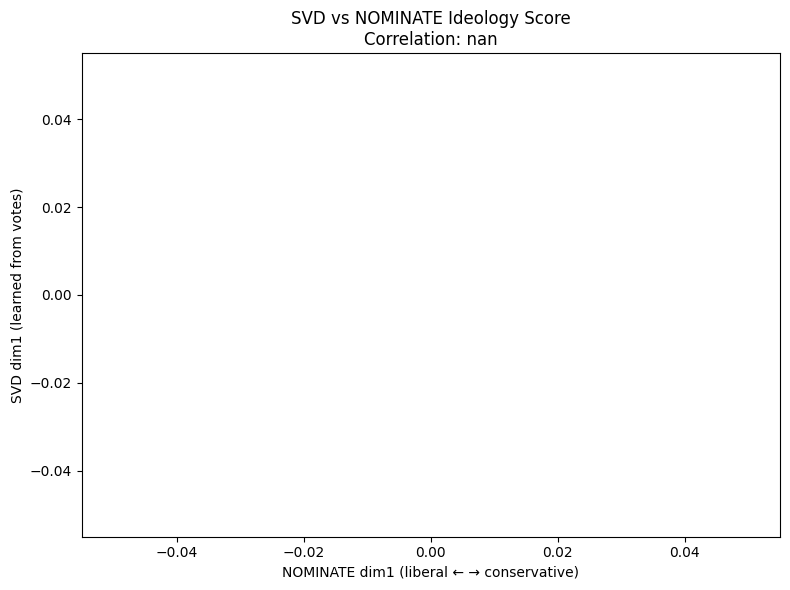

In [32]:
# compare SVD dim1 to NOMINATE dim1 — they should correlate strongly
senators_df    = pd.read_csv('../../data/senators/all_senators_with_bios.csv')
ideology_merge = svd_ideology.merge(
    senators_df[['id', 'nominate_dim1_y']],
    left_on='senator_id', right_on='id',
    how='inner'
).dropna(subset=['nominate_dim1_y'])

correlation = ideology_merge['svd_dim1'].corr(ideology_merge['nominate_dim1_y'])
print(f'Correlation between SVD dim1 and NOMINATE dim1: {correlation:.3f}')
print('(A value close to 1.0 or -1.0 means SVD recovered the ideology dimension)')

plt.figure(figsize=(8, 6))
plt.scatter(ideology_merge['nominate_dim1_y'], ideology_merge['svd_dim1'], alpha=0.6)
plt.xlabel('NOMINATE dim1 (liberal ← → conservative)')
plt.ylabel('SVD dim1 (learned from votes)')
plt.title(f'SVD vs NOMINATE Ideology Score\nCorrelation: {correlation:.3f}')
plt.tight_layout()
plt.show()

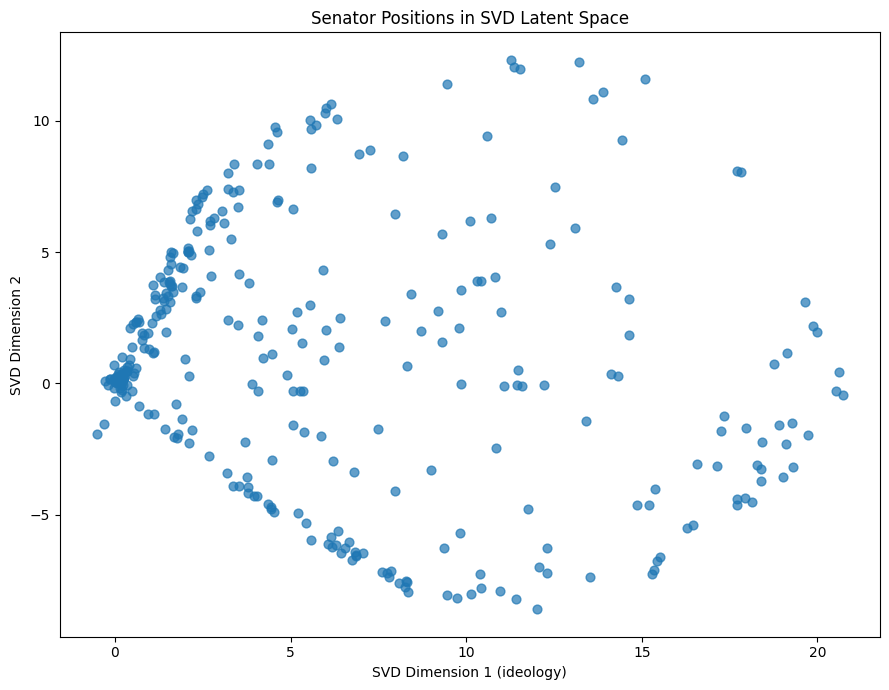

In [33]:
# plot senators in 2D latent space — should show clear party clustering
plt.figure(figsize=(9, 7))
plt.scatter(
    svd_ideology['svd_dim1'],
    svd_ideology['svd_dim2'],
    alpha=0.7, s=40
)
plt.xlabel('SVD Dimension 1 (ideology)')
plt.ylabel('SVD Dimension 2')
plt.title('Senator Positions in SVD Latent Space')
plt.tight_layout()
plt.show()

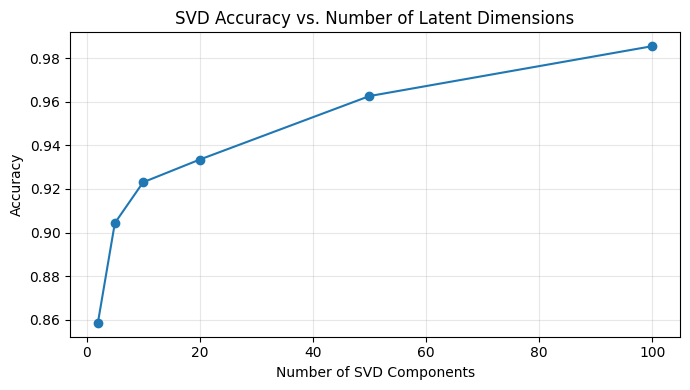

Best n_components: 100 (accuracy: 0.985)


In [34]:
# tune n_components: check accuracy vs. number of latent dimensions
component_range = [2, 5, 10, 20, 50, 100]
accuracies = []

for n in component_range:
    if n >= min(vote_matrix_filled.shape):
        break
    svd_test = TruncatedSVD(n_components=n, random_state=42)
    sf = svd_test.fit_transform(vote_matrix_filled)
    bf = svd_test.components_
    recon = sf @ bf

    preds = []
    acts  = []
    for _, row in sample.iterrows():
        sid = row['senator_id']
        bid = row['bill_id']
        if sid in senator_idx and bid in bill_idx:
            preds.append(1 if recon[senator_idx[sid], bill_idx[bid]] > 0 else -1)
            acts.append(row['vote_numeric'])

    accuracies.append(accuracy_score(acts, preds))

plt.figure(figsize=(7, 4))
plt.plot(component_range[:len(accuracies)], accuracies, marker='o')
plt.xlabel('Number of SVD Components')
plt.ylabel('Accuracy')
plt.title('SVD Accuracy vs. Number of Latent Dimensions')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

best_n = component_range[np.argmax(accuracies)]
print(f'Best n_components: {best_n} (accuracy: {max(accuracies):.3f})')

---
## Summary: Method Comparison

In [35]:
print('===== Results Summary =====')
print(f'Memory-based (k=10 neighbors):')
print(f'  Accuracy: {acc:.3f},  MAE: {mae:.3f}')
print()
print(f'SVD matrix factorization (n={N_COMPONENTS} components):')
print(f'  Accuracy: {acc_svd:.3f},  MAE: {mae_svd:.3f}')
print()
print('Note: both models are evaluated on KNOWN votes (upper bound on real performance).')
print('For a true holdout evaluation, mask votes before fitting and predict on held-out set.')

===== Results Summary =====
Memory-based (k=10 neighbors):
  Accuracy: 0.923,  MAE: 0.218

SVD matrix factorization (n=20 components):
  Accuracy: 0.933,  MAE: 0.300

Note: both models are evaluated on KNOWN votes (upper bound on real performance).
For a true holdout evaluation, mask votes before fitting and predict on held-out set.
